# Import Libraries

In [24]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from category_encoders import CountEncoder
from sklearn.preprocessing import StandardScaler
from pandas.plotting import parallel_coordinates

# Load Data

In [25]:
# Load dataset directly from UCI
url = "https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition"

#Column names, those we want
#columns = ["Gender", "Age", "Height", "Weight", "family_history_with_overweight", "FAVC", "FCVC", "NCP", "CAEC", "SMOKE"]

# Read data
df = pd.read_csv( "ObesityDataSet_raw_and_data_sinthetic.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

# Report on the Variance and Cordinality of each column in Data Set

In [26]:
# Report on the variance
num_df = df.select_dtypes(include=['int64', 'float64'])
variances = num_df.var()
print(variances.sort_values())

Height      0.008706
FCVC        0.285078
TUE         0.370792
CH2O        0.375712
NCP         0.605344
FAF         0.723507
Age        40.271313
Weight    685.977477
dtype: float64


In [27]:
# Report on cardinality
# Select categorical/object columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
# Calculate cardinality
cardinality = df[cat_cols].nunique()
print(cardinality)

Gender                            2
family_history_with_overweight    2
FAVC                              2
CAEC                              4
SMOKE                             2
SCC                               2
CALC                              4
MTRANS                            5
NObeyesdad                        7
dtype: int64


In [28]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


# Distribution of each Column

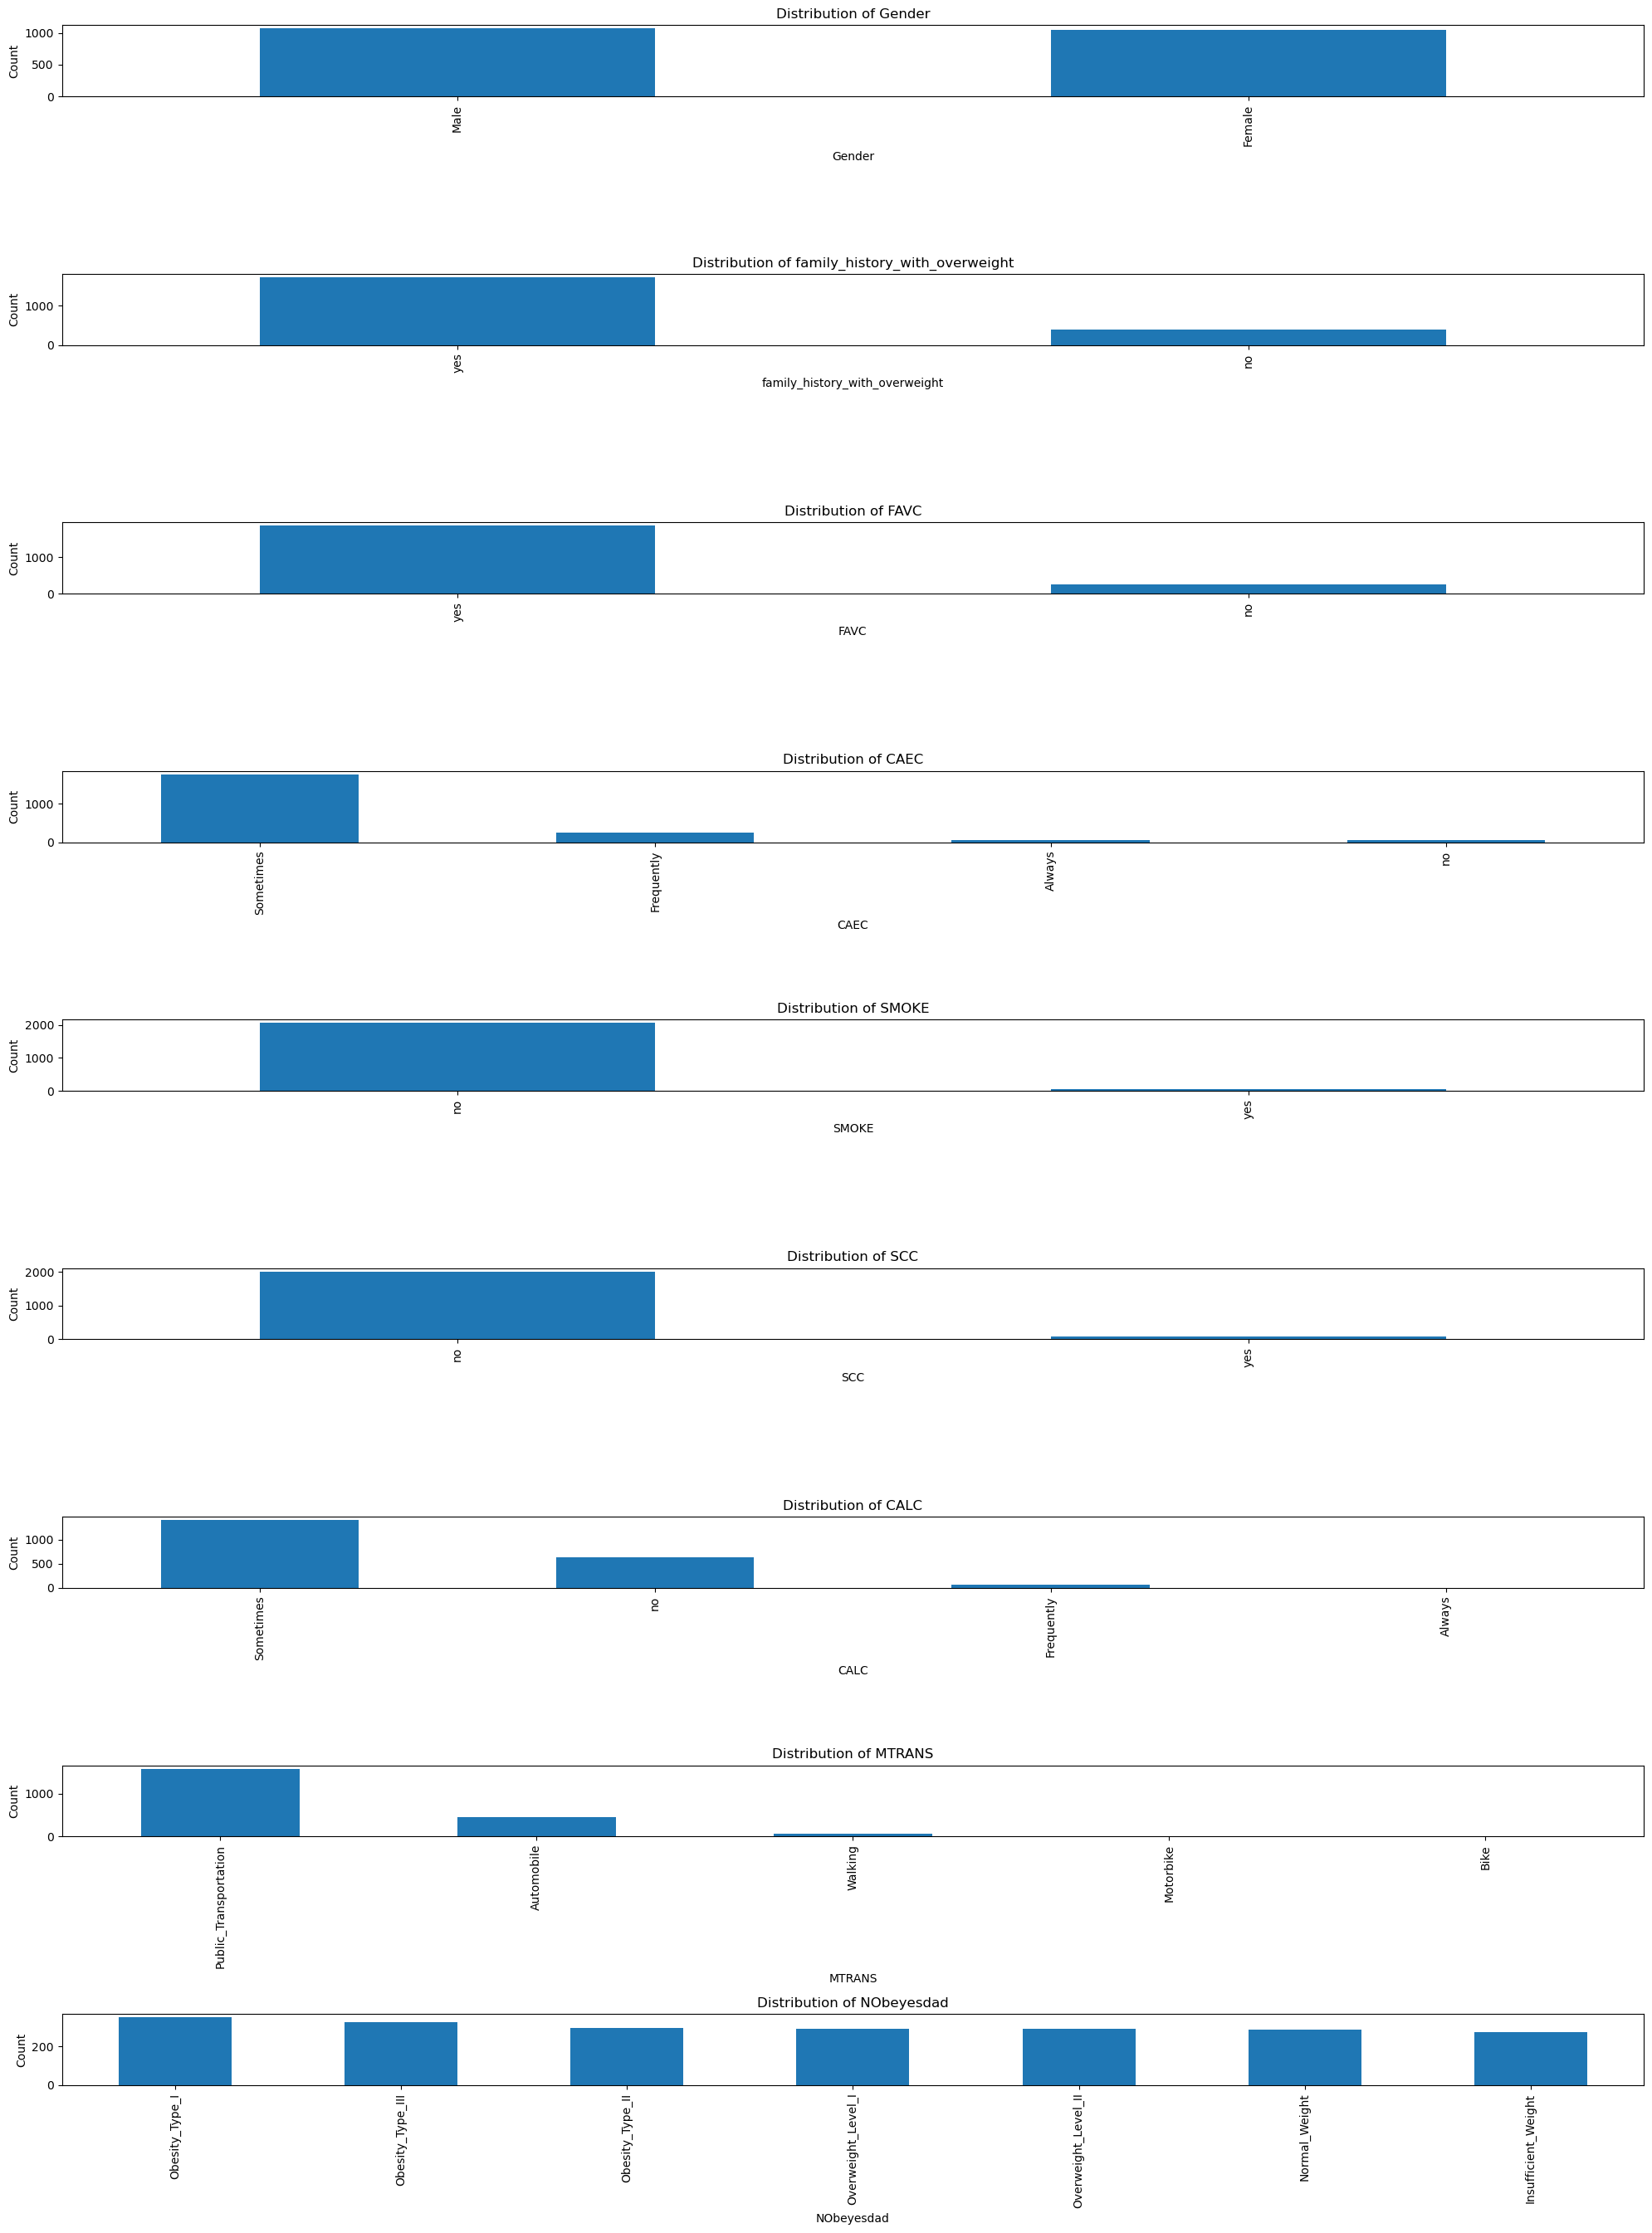

In [29]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# number of columns
n = len(cat_cols)

plt.figure(figsize=(20, 3*n))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n, 1, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# Removing unwanted columns

In [30]:
# Based on the previous cell, there are some columns that we remove since they have low entropy o low information variance,
# Also, we remove Target, which is "NObeyesdad"
# Separate the Target or y
y_ground_truth = df["NObeyesdad"].copy()

# Drop the specifc column 
df = df.drop(columns=['SMOKE', 'SCC', 'NObeyesdad'])

# Now for the rest of the columns, we want to see what is the percentage breakdown

In [31]:
# percentage breakdown of the unique values within each of those columns
cat_cols = df.select_dtypes(include=['object','category']).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True))


Column: Gender
Gender
Male      0.505921
Female    0.494079
Name: proportion, dtype: float64

Column: family_history_with_overweight
family_history_with_overweight
yes    0.817622
no     0.182378
Name: proportion, dtype: float64

Column: FAVC
FAVC
yes    0.883941
no     0.116059
Name: proportion, dtype: float64

Column: CAEC
CAEC
Sometimes     0.836097
Frequently    0.114638
Always        0.025107
no            0.024159
Name: proportion, dtype: float64

Column: CALC
CALC
Sometimes     0.663667
no            0.302700
Frequently    0.033160
Always        0.000474
Name: proportion, dtype: float64

Column: MTRANS
MTRANS
Public_Transportation    0.748460
Automobile               0.216485
Walking                  0.026528
Motorbike                0.005211
Bike                     0.003316
Name: proportion, dtype: float64


# Balance and Imbalanced Columns of Categorical columns

In [32]:
# Which columns are balanced and which are imbalanced
imbalance_threshold = 0.60
balanced_cols = []
imbalanced_cols = []

for col in cat_cols:
    max_ratio = df[col].value_counts(normalize=True, dropna=False).max()
    
    if max_ratio > imbalance_threshold:
        imbalanced_cols.append(col)
    else:
        balanced_cols.append(col)

print("Balanced columns:", balanced_cols)
print("Imbalanced columns:", imbalanced_cols)


for col in imbalanced_cols:
    freq_map = df[col].value_counts(normalize=True, dropna=False)
    df[col] = df[col].map(freq_map)



Balanced columns: ['Gender']
Imbalanced columns: ['family_history_with_overweight', 'FAVC', 'CAEC', 'CALC', 'MTRANS']


# Converting categorical columns to numerical with One-Hot encoding for a balanced dataset and CountEncoder for imbalanced

In [33]:
# This is applied on imbalanced_cols
# Use the correct variable name and add normalize=True for percentages
ce_freq = CountEncoder(cols=imbalanced_cols, normalize=True)

# Fit and transform your dataframe
df = ce_freq.fit_transform(df)

# This is applied only on balanced_cols 
df = pd.get_dummies(df, columns=balanced_cols, dtype=int)

# Spotting Collinearity, Not Predicting 

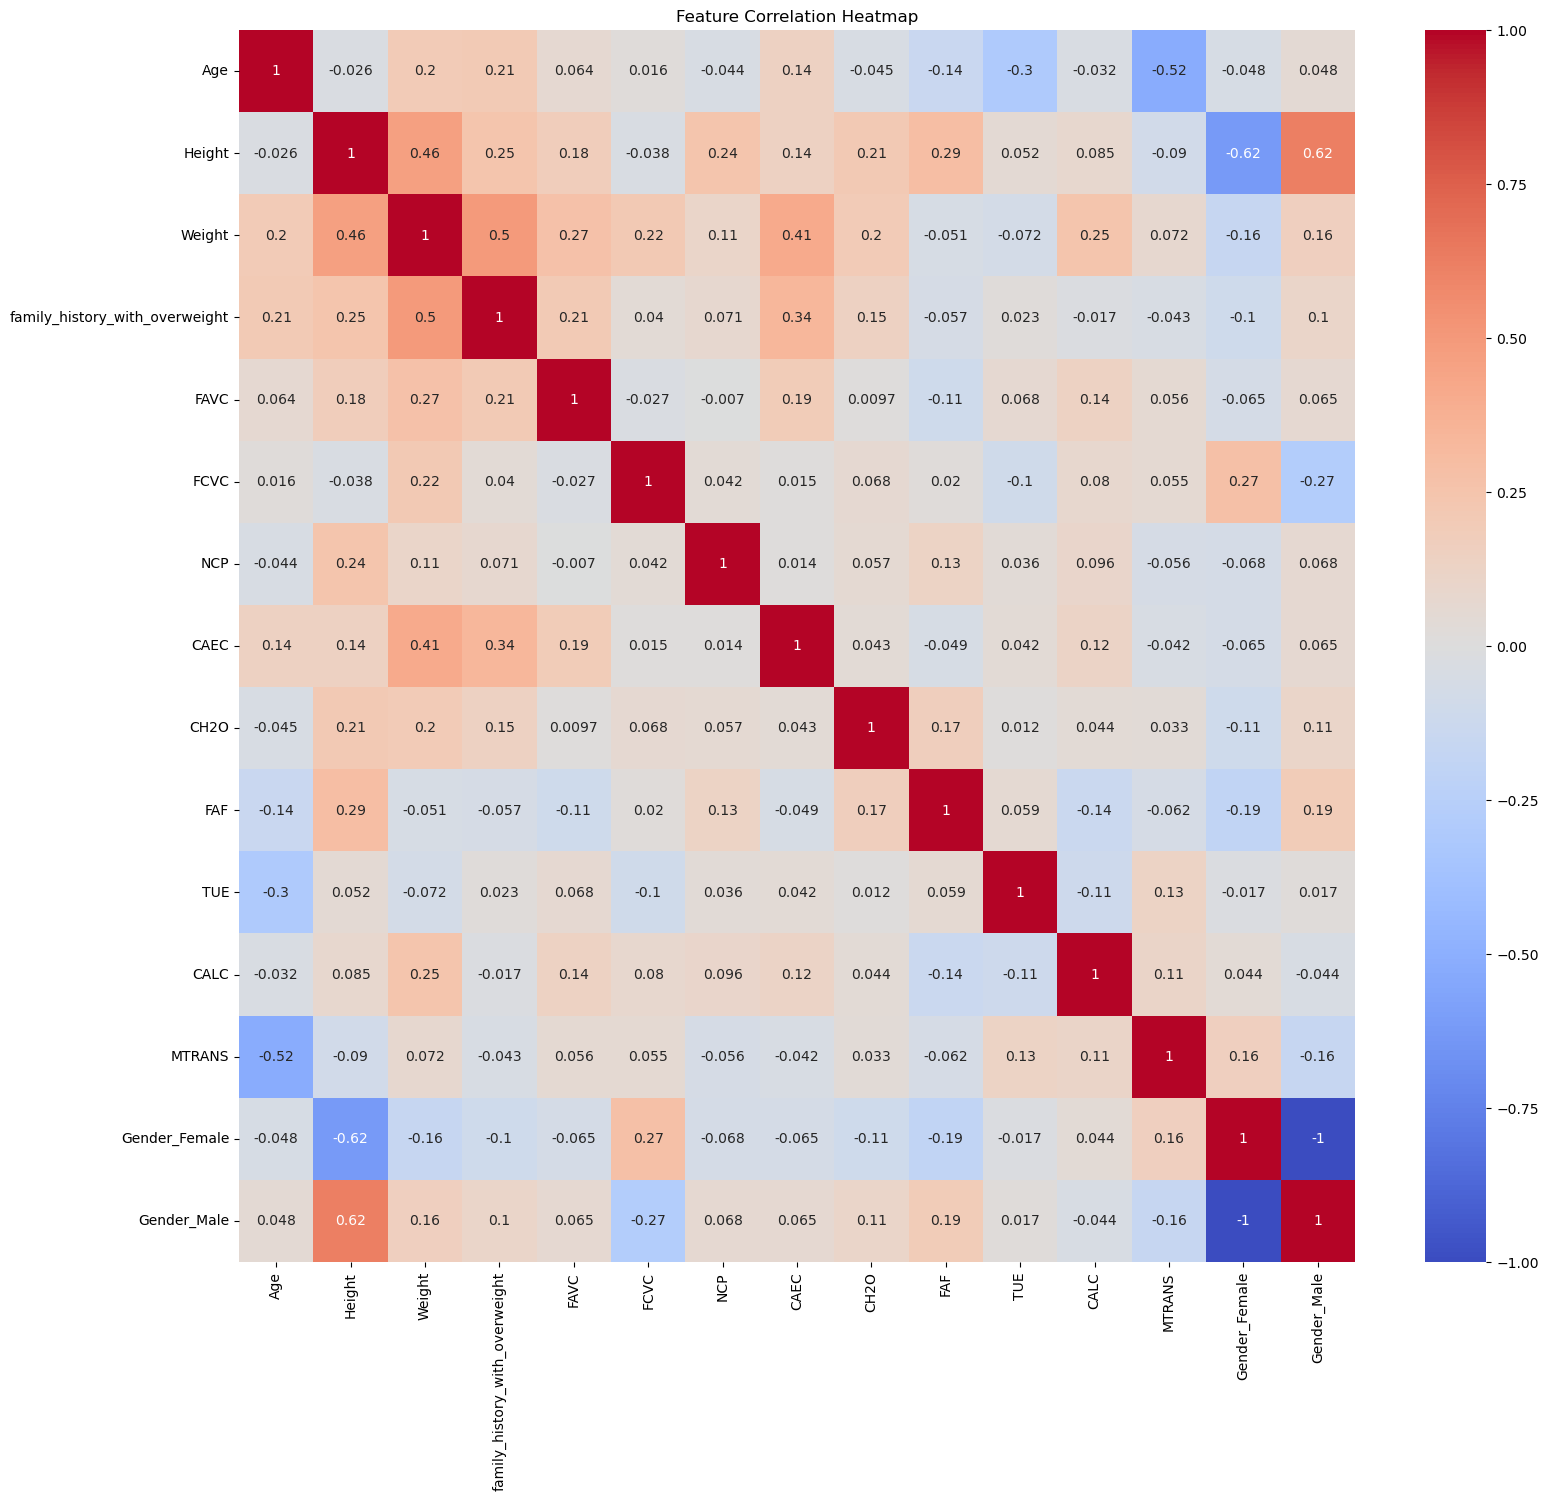

In [34]:
# Heat map
corr = df.corr()
plt.figure(figsize=(18,16))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# Scaling the numerical columns to be ready for the K-means model

In [35]:
num_cols=['Age', 'Weight', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])
df_scaled

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,MTRANS,Gender_Female,Gender_Male
0,-0.522124,-0.875589,-0.862558,0.817622,0.116059,-0.785019,0.404153,0.836097,-0.013073,-1.188039,0.561997,0.302700,0.748460,1,0
1,-0.522124,-1.947599,-1.168077,0.817622,0.116059,1.088342,0.404153,0.836097,1.618759,2.339750,-1.080625,0.663667,0.748460,1,0
2,-0.206889,1.054029,-0.366090,0.817622,0.116059,-0.785019,0.404153,0.836097,-0.013073,1.163820,0.561997,0.033160,0.748460,0,1
3,0.423582,1.054029,0.015808,0.182378,0.116059,1.088342,0.404153,0.836097,-0.013073,1.163820,-1.080625,0.033160,0.026528,0,1
4,-0.364507,0.839627,0.122740,0.182378,0.116059,-0.785019,-2.167023,0.836097,-0.013073,-1.188039,-1.080625,0.663667,0.748460,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,-0.525774,0.097045,1.711763,0.817622,0.883941,1.088342,0.404153,0.836097,-0.456705,0.783135,0.407996,0.663667,0.748460,1,0
2107,-0.367195,0.502844,1.800914,0.817622,0.883941,1.088342,0.404153,0.836097,-0.004702,0.389341,-0.096251,0.663667,0.748460,1,0
2108,-0.281909,0.541672,1.798868,0.817622,0.883941,1.088342,0.404153,0.836097,0.075361,0.474971,-0.019018,0.663667,0.748460,1,0
2109,0.007776,0.404927,1.785780,0.817622,0.883941,1.088342,0.404153,0.836097,1.377801,0.151471,-0.117991,0.663667,0.748460,1,0


# Model

In [36]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
df_scaled["cluster"] = kmeans.fit_predict(df_scaled)


# Save Model

In [37]:

joblib.dump(kmeans, "model/kmeans_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(ce_freq, "model/frequency_encoder.pkl")

['model/frequency_encoder.pkl']

# Plot Clusters

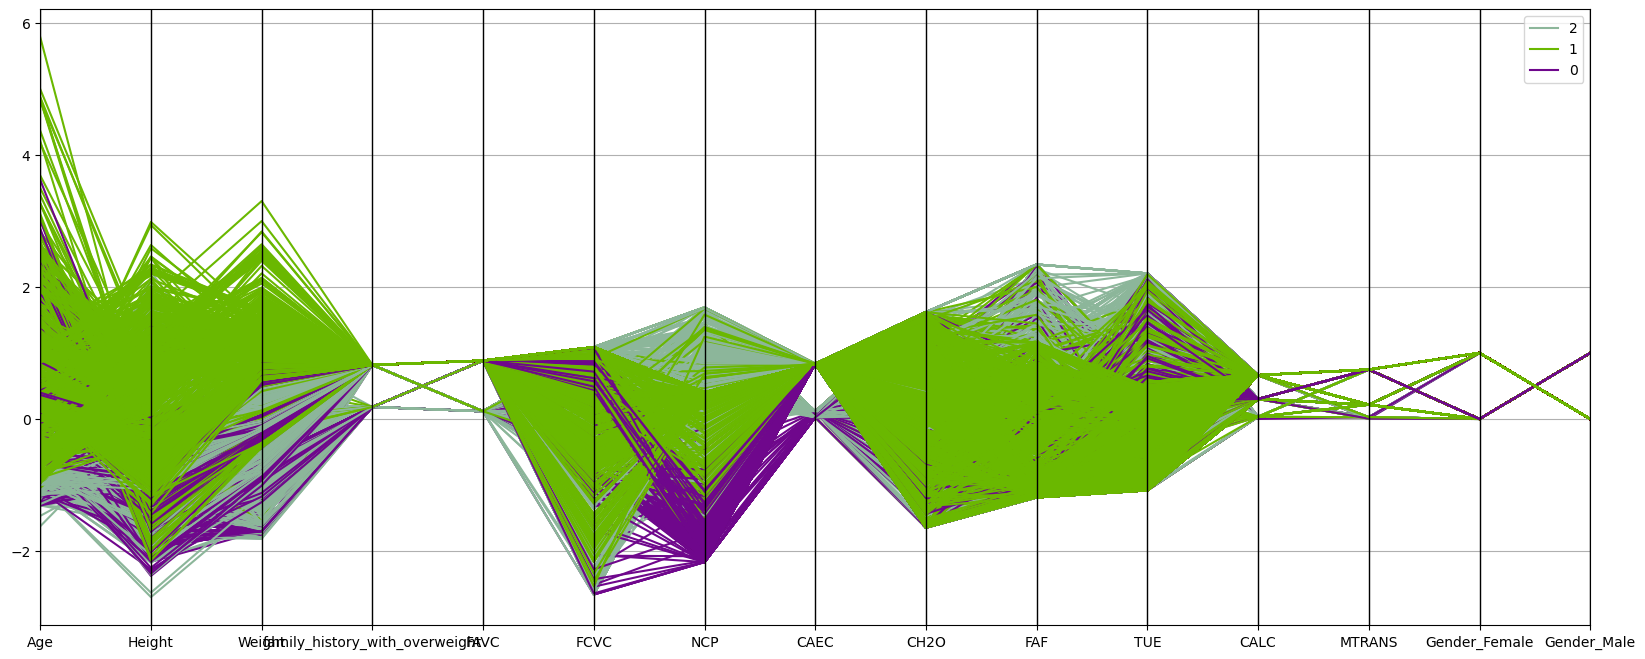

In [38]:
df_plot = df_scaled.copy()
plt.figure(figsize=(20,8))
parallel_coordinates(df_plot, "cluster")
plt.show()

# Representative of each cluster, mean

In [39]:
df_cluster = df_scaled.copy()
cluster_means = df_cluster.groupby("cluster").mean()
cluster_means

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,MTRANS,Gender_Female,Gender_Male
cluster,,,,,,,,,,,,,,,
0,-0.107049,-0.728695,-0.537520,0.615182,0.774244,-0.113944,-1.885246,0.650522,-0.179422,-0.272801,-0.046607,0.482630,0.638676,0.645604,0.354396
1,0.526771,0.355543,0.813268,0.795154,0.854312,0.322213,0.268723,0.806138,0.178496,-0.152307,-0.309498,0.594733,0.571931,0.455520,0.544480
2,-0.555911,-0.081667,-0.691796,0.633448,0.735836,-0.318365,0.535026,0.635256,-0.124358,0.296562,0.375586,0.485234,0.635107,0.470516,0.529484


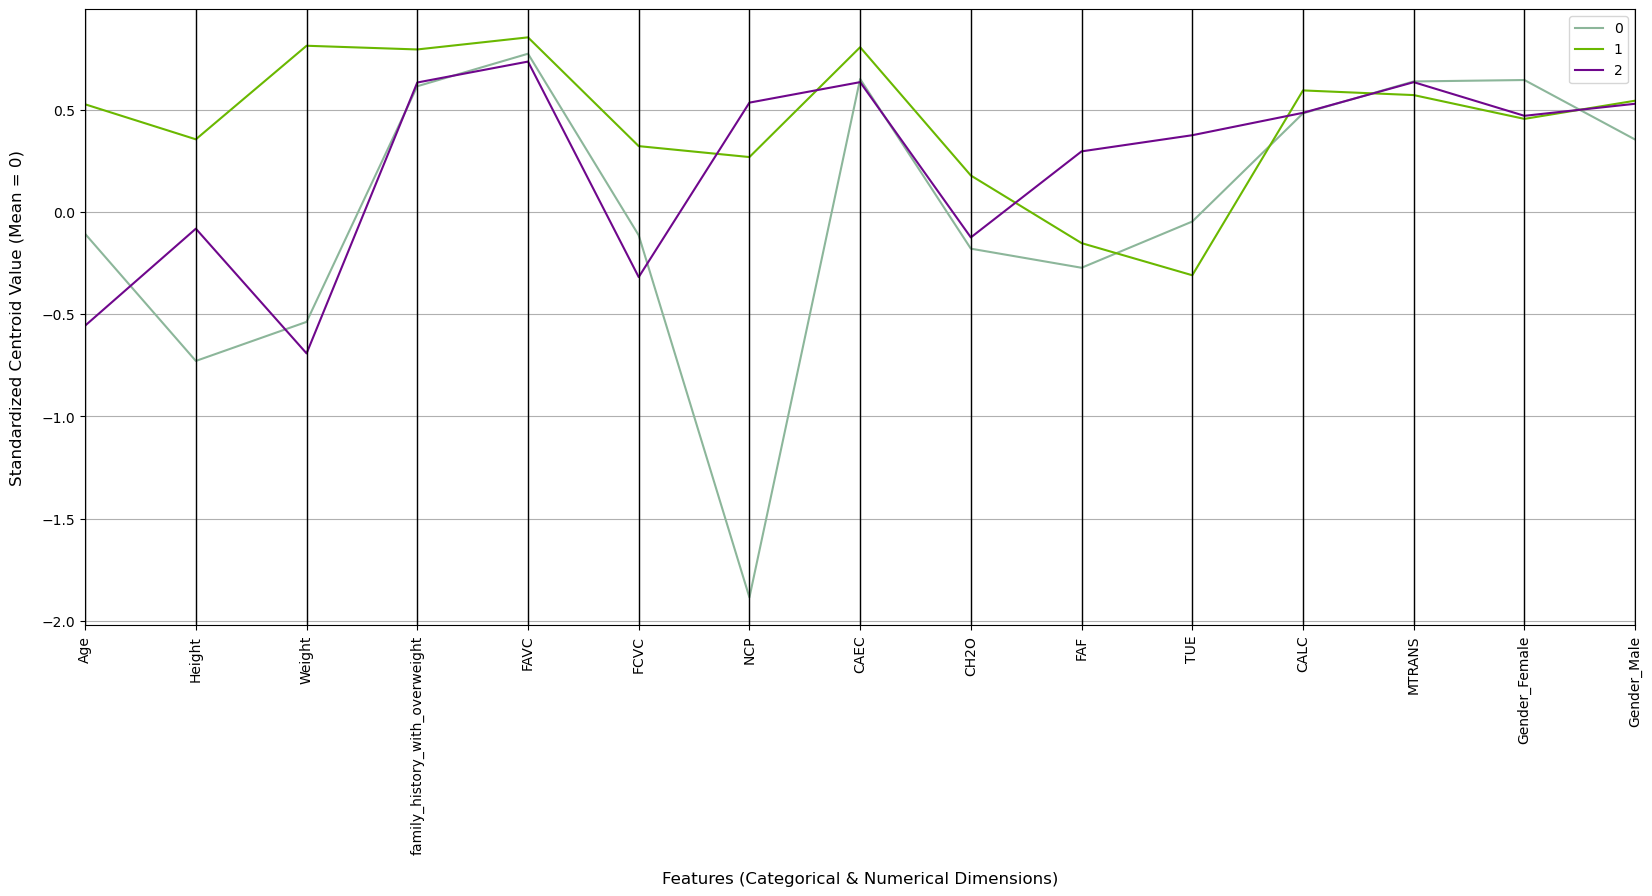

In [40]:
#Each cluster's representative
cluster_means = df_scaled.copy()
cluster_means = cluster_means.groupby("cluster").mean().reset_index()
plt.figure(figsize=(20,8))
plt.xlabel("Features (Categorical & Numerical Dimensions)", fontsize=12, labelpad=12)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("Standardized Centroid Value (Mean = 0)", fontsize=12, labelpad=12)
parallel_coordinates(cluster_means, "cluster")
plt.show()

# Most Distinguishing Features

In [41]:
importance = cluster_means.var().sort_values(ascending=False)
importance.head(10)

NCP              1.761369
cluster          1.000000
Weight           0.685608
Height           0.297562
Age              0.295901
TUE              0.119450
FCVC             0.107060
FAF              0.090029
CH2O             0.037143
Gender_Female    0.011169
dtype: float64

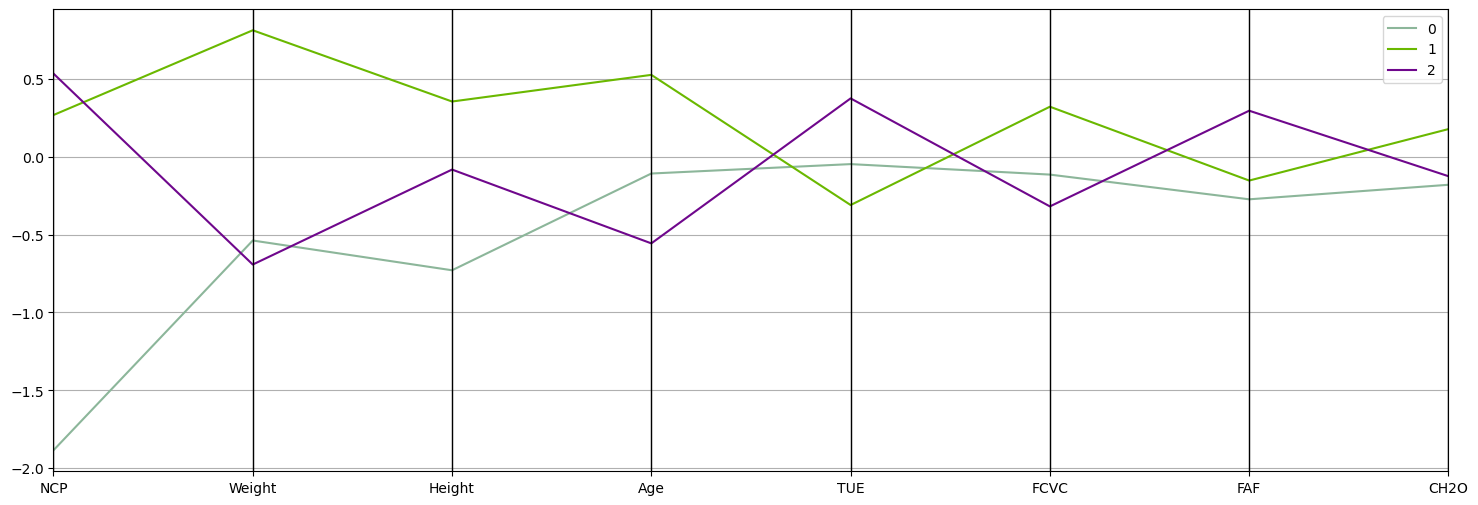

In [42]:
importance = cluster_means.drop("cluster", axis=1).var().sort_values(ascending=False)

top_features = importance.head(8).index

cluster_means_small = cluster_means[["cluster"] + list(top_features)]

plt.figure(figsize=(18,6))
parallel_coordinates(cluster_means_small, "cluster")
plt.show()

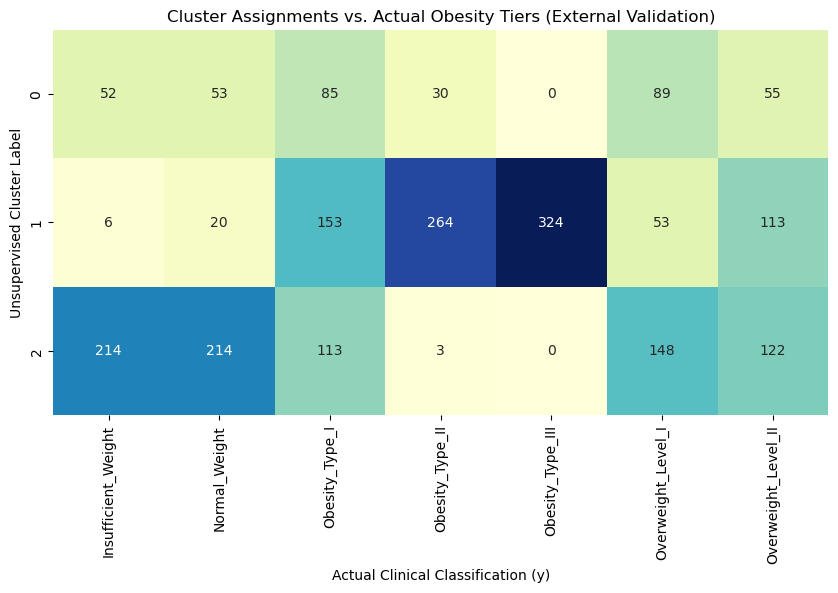

In [43]:
# Cross-tabulate unsupervised clusters against external ground truth
validation_matrix = pd.crosstab(df_scaled['cluster'], y_ground_truth)

# Visualize the alignment using a validation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(validation_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Cluster Assignments vs. Actual Obesity Tiers (External Validation)")
plt.ylabel("Unsupervised Cluster Label")
plt.xlabel("Actual Clinical Classification (y)")
plt.show()